<a href="https://colab.research.google.com/github/AdrNicole/DATA-ANALYTICS/blob/Modulo2_Programacion-con-Python-para-el-analisis-de-datos/D2_Clase6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío- Transformación y manipulación de datos (Parte II)

Le solicitan analizar información sobre las ventas realizadas por los equipos de ventas de ADL, incluyendo detalles sobre los productos vendidos, los clientes, las fechas de los pedidos y los plazos de entrega.

Para resolver este desafío deberás cargar datos desde Hojas de Excel del archivo

`US_Regional_Sales_Data.xlsx.`

En base a esto, debe generar una visualización de datos como la que se muestra en las hojas Reporte1 y Reporte2 del archivo `reporte.xlsx.`
Para cumplir con lo solicitado, puedes aplicar los siguientes pasos:

1. Carga los datos de cada pestaña del archivo `US_Regional_Sales_Data.xlsx` en un
DataFrame independiente. (hint: Puedes obtener los nombres de las hojas usando lo siguiente)

`pd.ExcelFile(archivo).sheet_names`

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# obtener nombres de las hojas
pd.ExcelFile('US_Regional_Sales_Data.xlsx').sheet_names

['Sales Orders Sheet',
 'Customers Sheet',
 'Store Locations Sheet',
 'Products Sheet',
 'Sales Team Sheet']

In [ ]:
# Cargar las dos hojas en DataFrames distintos
archivo = 'US_Regional_Sales_Data.xlsx'
df_regional_hoja1 = pd.read_excel(archivo, sheet_name=0) # Primera hoja
df_regional_hoja2 = pd.read_excel(archivo, sheet_name=1) # Segunda hoja
df_regional_hoja3 = pd.read_excel(archivo, sheet_name=2) # Tercera hoja
df_regional_hoja4 = pd.read_excel(archivo, sheet_name=3) # Cuarta hoja
df_regional_hoja5 = pd.read_excel(archivo, sheet_name=4) # Quinta hoja

In [ ]:
# mostrar las primeras filas para verificar
print(f'Primera Hoja con dimensiones {df_regional_hoja1.shape}:')
print(df_regional_hoja1.head())

print(f'\nSegunda Hoja con dimensiones {df_regional_hoja2.shape}:')
print(df_regional_hoja2.head())

print(f'\nTercera Hoja con dimensiones {df_regional_hoja3.shape}:')
print(df_regional_hoja3.head())

print(f'\nCuarta Hoja con dimensiones {df_regional_hoja4.shape}:')
print(df_regional_hoja4.head())

print(f'\nQuinta Hoja con dimensiones {df_regional_hoja5.shape}:')
print(df_regional_hoja5.head())

Primera Hoja con dimensiones (7991, 16):
   OrderNumber Sales Channel WarehouseCode ProcuredDate  OrderDate   ShipDate  \
0  SO - 000101      In-Store  WARE-UHY1004   2017-12-31 2018-05-31 2018-06-14   
1  SO - 000102        Online  WARE-NMK1003   2017-12-31 2018-05-31 2018-06-22   
2  SO - 000103   Distributor  WARE-UHY1004   2017-12-31 2018-05-31 2018-06-21   
3  SO - 000104     Wholesale  WARE-NMK1003   2017-12-31 2018-05-31 2018-06-02   
4  SO - 000105   Distributor  WARE-NMK1003   2018-04-10 2018-05-31 2018-06-16   

  DeliveryDate CurrencyCode  _SalesTeamID  _CustomerID  _StoreID  _ProductID  \
0   2018-06-19          USD             6           15       259          12   
1   2018-07-02          USD            14           20       196          27   
2   2018-07-01          USD            21           16       213          16   
3   2018-06-07          USD            28           48       107          23   
4   2018-06-26          USD            22           49       111        

2. Cruza todos los DataFrames usando validación many_to_one, y guarda el resultado en una nueva variable llamada df_base.

In [ ]:
df1 = df_regional_hoja1.merge(df_regional_hoja2,
                            on = '_CustomerID',
                            how ='left',
                            validate = 'many_to_one')
df2 = df1.merge(df_regional_hoja3,
                on = '_StoreID',
                how = 'left',
                validate = 'many_to_one')
df3 = df2.merge(df_regional_hoja4,
                on = '_ProductID',
                how = 'left',
                validate = 'many_to_one')
df_base = df3.merge(df_regional_hoja5,
                    on = '_SalesTeamID',
                    how = 'left',
                    validate = 'many_to_one')

In [ ]:
df_base.shape
df_base.columns.to_list()
df_base.head()

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,...,AreaCode,Population,Household Income,Median Income,Land Area,Water Area,Time Zone,Product Name,Sales Team,Region
0,SO - 000101,In-Store,WARE-UHY1004,2017-12-31,2018-05-31,2018-06-14,2018-06-19,USD,6,15,...,631,213776,68789,80327,135481314,160302131,America/New York,Dining Furniture,Joshua Bennett,Northeast
1,SO - 000102,Online,WARE-NMK1003,2017-12-31,2018-05-31,2018-06-22,2018-07-02,USD,14,20,...,913,186515,74830,72463,194562941,1309517,America/Chicago,Wreaths,Paul Holmes,Midwest
2,SO - 000103,Distributor,WARE-UHY1004,2017-12-31,2018-05-31,2018-06-21,2018-07-01,USD,21,16,...,734,117070,47179,55990,72727009,2254528,America/Detroit,Stemware,Samuel Fowler,Midwest
3,SO - 000104,Wholesale,WARE-NMK1003,2017-12-31,2018-05-31,2018-06-02,2018-06-07,USD,28,48,...,203,130322,49771,37192,48407373,3739487,America/New York,Accessories,Carlos Miller,West
4,SO - 000105,Distributor,WARE-NMK1003,2018-04-10,2018-05-31,2018-06-16,2018-06-26,USD,22,49,...,203,108802,40213,40467,73880017,1086045,America/New York,Candles,Joe Price,Northeast


3. Agrega las siguientes columnas a df_ base:


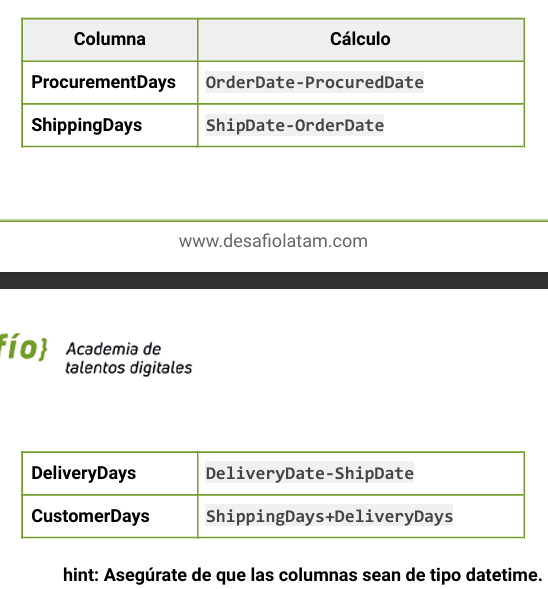

In [ ]:
df_base['OrderDate'] = pd.to_datetime(df_base['OrderDate'])
df_base['ProcuredDate'] = pd.to_datetime(df_base['ProcuredDate'])
df_base['ShipDate'] = pd.to_datetime(df_base['ShipDate'])
df_base['DeliveryDate'] = pd.to_datetime(df_base['DeliveryDate'])
#df_base['ShippingDays'] = pd.to_datetime(df_base['ShippingDays'])

df_base['ProcurementDays'] = df_base['OrderDate'] - df_base['ProcuredDate']
df_base['ShippingDays'] = df_base['ShipDate'] - df_base['OrderDate']
df_base['DeliveryDays'] = df_base['DeliveryDate'] - df_base['ShipDate']
df_base['CustomerDays'] = df_base['ShippingDays'] + df_base['DeliveryDays']

print(f'Dimensiones: {df_base.shape}')
df_base.tail(10)

Dimensiones: (7991, 38)


,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,...,Land Area,Water Area,Time Zone,Product Name,Sales Team,Region,ProcurementDays,ShippingDays,DeliveryDays,CustomerDays
7981,SO - 0008082,Distributor,WARE-PUJ1005,2020-09-26,2020-12-29,2021-01-07,2021-01-11,USD,22,12,...,200434440,4155432,America/New York,Furniture Cushions,Joe Price,Northeast,94 days,9 days,4 days,13 days
7982,SO - 0008083,In-Store,WARE-NMK1003,2020-09-26,2020-12-29,2021-01-21,2021-01-26,USD,4,42,...,62261002,1737713,America/New York,Floral,Chris Armstrong,Northeast,94 days,23 days,5 days,28 days
7983,SO - 0008084,Distributor,WARE-NMK1003,2020-09-26,2020-12-29,2021-01-20,2021-01-30,USD,22,44,...,55623172,3481216,America/New York,Wine Storage,Joe Price,Northeast,94 days,22 days,10 days,32 days
7984,SO - 0008085,In-Store,WARE-PUJ1005,2020-09-26,2020-12-29,2021-01-11,2021-01-12,USD,8,19,...,143423857,7692318,America/New York,Floral,George Lewis,West,94 days,13 days,1 days,14 days
7985,SO - 0008086,In-Store,WARE-NBV1002,2020-09-26,2020-12-29,2021-01-09,2021-01-11,USD,5,27,...,103562370,24723,America/Los Angeles,Candles,Stephen Payne,South,94 days,11 days,2 days,13 days
7986,SO - 0008087,In-Store,WARE-MKL1006,2020-09-26,2020-12-30,2021-01-07,2021-01-14,USD,9,41,...,155255892,5940332,America/Chicago,Pendants,Joshua Ryan,Midwest,95 days,8 days,7 days,15 days
7987,SO - 0008088,Online,WARE-NMK1003,2020-09-26,2020-12-30,2021-01-02,2021-01-04,USD,14,29,...,139369271,259576,America/Chicago,Table Lamps,Paul Holmes,Midwest,95 days,3 days,2 days,5 days
7988,SO - 0008089,Online,WARE-UHY1004,2020-09-26,2020-12-30,2021-01-23,2021-01-26,USD,14,32,...,85627013,4850146,America/New York,Table Linens,Paul Holmes,Midwest,95 days,24 days,3 days,27 days
7989,SO - 0008090,Online,WARE-NMK1003,2020-09-26,2020-12-30,2021-01-20,2021-01-25,USD,20,42,...,73880017,1086045,America/New York,Clocks,Anthony Torres,West,95 days,21 days,5 days,26 days
7990,SO - 0008091,In-Store,WARE-UHY1004,2020-09-26,2020-12-30,2021-01-13,2021-01-19,USD,6,41,...,343173025,3173027,America/New York,Festive,Joshua Bennett,Northeast,95 days,14 days,6 days,20 days


4. Agrega una nueva columna discreta al df_base, con el nombre CustomerDaysInterval
que clasifique los valores de la columna CustomerDays en los siguientes intervalos:
*   0 to 15 days
*   15 to 30 days
*   30 to 45 days
*   45 to 60 days
*   60 to 75 days
*   75 to 90 days

In [ ]:
# convertir la fecha a dias numericos
df_base['CustomerDays_dias'] = df_base['CustomerDays'].dt.days
# intervalos
df_base['CustomerDaysInterval'] = pd.cut(df_base['CustomerDays_dias'],
                                      bins = [0,15,30,45,60,75,90],
                                      labels = ['0 to 15 days','15 to 30 days','30 to 45 days',
                                                '45 to 60 days','60 to 75 days','75 to 90 days'])
df_base[['CustomerDays','CustomerDaysInterval']].head()

,CustomerDays,CustomerDaysInterval
0,19 days,15 to 30 days
1,32 days,30 to 45 days
2,31 days,30 to 45 days
3,7 days,0 to 15 days
4,26 days,15 to 30 days


5. Utiliza una tabla pivote para mostrar el conteo de **órdenes** agrupando por **Sales
Team** en las filas y **CustomerDaysInterval** en las columnas. Este reporte debe
cuadrar con los datos de la pestaña `Reporte1 `del archivo `reportes.xlsx`


In [ ]:
pd.ExcelFile('/content/reportes.xlsx').sheet_names

['Reporte1', 'Reporte2']

In [ ]:
archivo2= '/content/reportes.xlsx'
df_reporte_hoja1 = pd.read_excel(archivo2, sheet_name=0) # Primera hoja
df_reporte_hoja2 = pd.read_excel(archivo2, sheet_name=1) # Segunda hoja

df_reporte_hoja1

,Sales Team,0 to 15 days,15 to 30 days,30 to 45 days,45 to 60 days,60 to 75 days,75 to 90 days,All
0,Adam Hernandez,81,179,42,0,0,0,302
1,Anthony Berry,76,181,41,0,0,0,298
2,Anthony Torres,81,162,45,0,0,0,288
3,Carl Nguyen,96,178,40,0,0,0,314
4,Carlos Miller,65,148,34,0,0,0,247
5,Chris Armstrong,92,156,44,0,0,0,292
6,Donald Reynolds,97,163,36,0,0,0,296
7,Douglas Tucker,87,145,45,0,0,0,277
8,Frank Brown,85,150,40,0,0,0,275
9,George Lewis,104,169,42,0,0,0,315


In [ ]:
TablaPivote = pd.pivot_table(
                             df_base, # tabla de extracción
                             values = 'OrderNumber', # lo que se va a contar
                             columns = 'CustomerDaysInterval', # columnas
                             index = 'Sales Team', # filas
                             aggfunc ='count', # contar values
                             margins = True # totales
                             )

# reemplazamos los NaN por cero
TablaPivote = TablaPivote.fillna(0)
TablaPivote

/tmp/ipykernel_3761/200466745.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  TablaPivote = pd.pivot_table(


CustomerDaysInterval,0 to 15 days,15 to 30 days,30 to 45 days,45 to 60 days,60 to 75 days,75 to 90 days,All
Sales Team,,,,,,,
Adam Hernandez,81,179,42,0.0,0.0,0.0,302
Anthony Berry,76,181,41,0.0,0.0,0.0,298
Anthony Torres,81,162,45,0.0,0.0,0.0,288
Carl Nguyen,96,178,40,0.0,0.0,0.0,314
Carlos Miller,65,148,34,0.0,0.0,0.0,247
Chris Armstrong,92,156,44,0.0,0.0,0.0,292
Donald Reynolds,97,163,36,0.0,0.0,0.0,296
Douglas Tucker,87,145,45,0.0,0.0,0.0,277
Frank Brown,85,150,40,0.0,0.0,0.0,275


6. Agrega la siguiente columna calculada a la base:

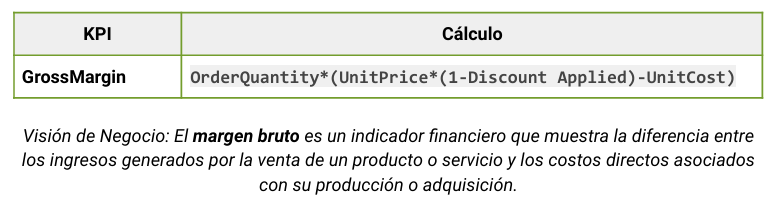

In [ ]:
df_base.columns

Index(['OrderNumber', 'Sales Channel', 'WarehouseCode', 'ProcuredDate',
       'OrderDate', 'ShipDate', 'DeliveryDate', 'CurrencyCode', '_SalesTeamID',
       '_CustomerID', '_StoreID', '_ProductID', 'Order Quantity',
       'Discount Applied', 'Unit Price', 'Unit Cost', 'Customer Names',
       'City Name', 'County', 'StateCode', 'State', 'Type', 'Latitude',
       'Longitude', 'AreaCode', 'Population', 'Household Income',
       'Median Income', 'Land Area', 'Water Area', 'Time Zone', 'Product Name',
       'Sales Team', 'Region', 'ProcurementDays', 'ShippingDays',
       'DeliveryDays', 'CustomerDays', 'CustomerDays_dias',
       'CustomerDaysInterval', 'GrossMargin'],
      dtype='object')

In [ ]:
from numpy._core.defchararray import count
# verifico si hay algun impedimiento para hacer el calculo
subtabla = df_base[['Order Quantity','Unit Price','Discount Applied','Unit Cost']]
subtabla.dtypes

# reviso si hay algun nulo
for item in df_base[['Order Quantity','Unit Price','Discount Applied','Unit Cost']]:
  l = subtabla[item].isnull().sum()
  print(f'{item}: {l}')

# agregamos la columna calculada a la base
df_base['GrossMargin'] = df_base['Order Quantity']*(df_base['Unit Price']*(1-df_base['Discount Applied'])-df_base['Unit Cost'])

df_base[['GrossMargin']]

Order Quantity: 0
Unit Price: 0
Discount Applied: 0
Unit Cost: 0


,GrossMargin
0,4073.4325
1,886.4100
2,905.5050
3,5486.7640
4,1312.1280
...,...
7986,94.9725
7987,6725.4600
7988,1338.9950
7989,1286.4000


7. En esta parte debes aplicar un porcentaje a la columna GrossMargin, pero ese
porcentaje dependerá del intervalo en que se encuentre GrossMargin.

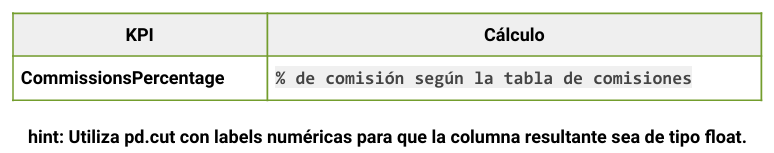

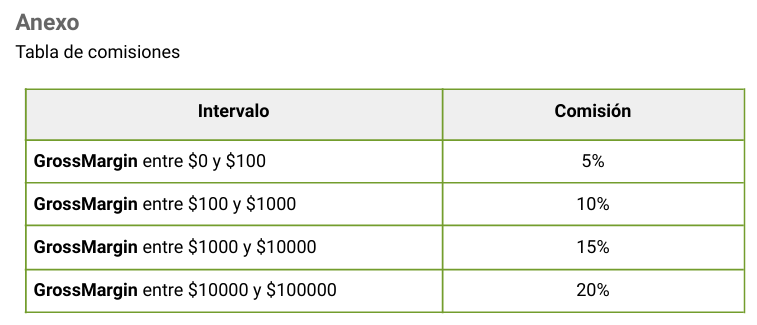


In [ ]:
df_reporte_hoja2
df_base['ComissionsPorcentage'] = pd.cut(df_base['GrossMargin'],
                                         bins = [0,100,1_000,10_000,100_000],
                                         labels = [0.05,0.1,0.15,0.2])
df_base['ComissionsPorcentage'] = df_base['ComissionsPorcentage'].astype(float)

df_base[['GrossMargin','ComissionsPorcentage']].head()
df_base[['GrossMargin','ComissionsPorcentage']].dtypes

,0
GrossMargin,float64
ComissionsPorcentage,float64


8. Calcula el monto de la comisión, utilizando la Tabla del Anexo.
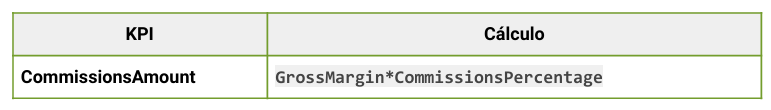


In [ ]:
df_base['CommissionsAmount'] = df_base['GrossMargin']*df_base['ComissionsPorcentage']
df_base[['Sales Team','CommissionsAmount']].head()
#df_base[['Sales Team','CommissionsAmount']].dtypes

,Sales Team,CommissionsAmount
0,Joshua Bennett,611.014875
1,Paul Holmes,88.641000
2,Samuel Fowler,90.550500
3,Carlos Miller,823.014600
4,Joe Price,196.819200


9. Calcula la comisión sobre el margen bruto.

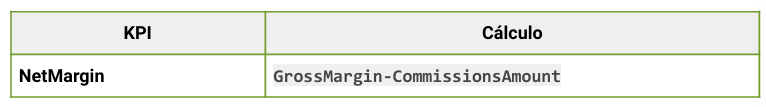

In [ ]:
df_base['NetMargin'] = df_base['GrossMargin'] - df_base['CommissionsAmount']
df_base[['NetMargin']].head()

,NetMargin
0,3462.417625
1,797.769000
2,814.954500
3,4663.749400
4,1115.308800


10. Utilizando una tabla pivote, muestra la suma de los valores GrossMargin, NetMargin y
CommissionAmount agrupando por Sales Team en las filas. Este reporte debe cuadrar con
los datos de la pestaña Reporte2 del archivo reportes.xlsx

In [ ]:
df_base.columns

Index(['OrderNumber', 'Sales Channel', 'WarehouseCode', 'ProcuredDate',
       'OrderDate', 'ShipDate', 'DeliveryDate', 'CurrencyCode', '_SalesTeamID',
       '_CustomerID', '_StoreID', '_ProductID', 'Order Quantity',
       'Discount Applied', 'Unit Price', 'Unit Cost', 'Customer Names',
       'City Name', 'County', 'StateCode', 'State', 'Type', 'Latitude',
       'Longitude', 'AreaCode', 'Population', 'Household Income',
       'Median Income', 'Land Area', 'Water Area', 'Time Zone', 'Product Name',
       'Sales Team', 'Region', 'ProcurementDays', 'ShippingDays',
       'DeliveryDays', 'CustomerDays', 'CustomerDays_dias',
       'CustomerDaysInterval', 'GrossMargin', 'ComissionsPorcentage',
       'CommissionsAmount', 'NetMargin'],
      dtype='object')

In [ ]:
TablaPivote2 = pd.pivot_table(
    df_base,
    #values = 'OrderNumber',
    values= ['GrossMargin', 'NetMargin', 'CommissionsAmount'],
    index = 'Sales Team',
    aggfunc= 'sum'
)

TablaPivote2.round(2).head()

,CommissionsAmount,GrossMargin,NetMargin
Sales Team,,,
Adam Hernandez,126637.21,779095.20,677987.33
Anthony Berry,124061.18,767943.95,654798.34
Anthony Torres,117962.21,743901.44,636758.05
Carl Nguyen,123843.21,774781.47,661874.73
Carlos Miller,110882.09,668752.93,580326.02


In [ ]:
df_reporte_hoja2.head()

,Sales Team,CommissionAmount,Gross Margin,Net Margin
0,Adam Hernandez,126637.21,779095.20,677987.33
1,Anthony Berry,124061.18,767943.95,654798.34
2,Anthony Torres,117962.21,743901.44,636758.05
3,Carl Nguyen,123843.21,774781.47,661874.73
4,Carlos Miller,110882.09,668752.93,580326.02
